# Dataset description
## Informality by Educational Level
**Source**: DANE

**Dataset**: [Empleo informal y seguridad social](https://www.dane.gov.co/index.php/estadisticas-por-tema/mercado-laboral/empleo-informal-y-seguridad-social)

# Code
## Imports

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text

pd.set_option("display.float_format", lambda x: "%.0f" % x)

## Load data

In [150]:
path = "./data/educacion.csv"

df = pd.read_csv(path, encoding="utf-8")

In [151]:
education_dict = {
    "Básica primaria": "Primary",
    "Ninguno": "None",
    "Educación media": "Upper secondary",
    "Básica secundaria": "Lower secondary",
    "Técnica profesional y Tecnológica": "Technical and technological",
    "Posgrado": "Postgraduate",
    "Universitaria": "University"
}

df_2026 = df[
    (df["Fecha"].eq(2026)) &
    (df["Perspectiva"].eq("Total nacional")) &
    (df["Periodo"].eq("Feb - Abr")) &
    (~df["Grupo"].eq("Población ocupada")) &
    (~df["Concepto"].isin(["Formal", "Informal"]))
].copy()

df_2026["Concepto"] = df_2026["Concepto"].str.replace(r"[\^*]", "", regex=True)

formal_informal = df_2026.groupby(["Grupo", "Concepto"])["Valor"].sum().mul(1000)

net_difference = round(formal_informal["Formal"] - formal_informal["Informal"], 0).sort_values()
net_difference.index = net_difference.index.map(education_dict)

## Plot

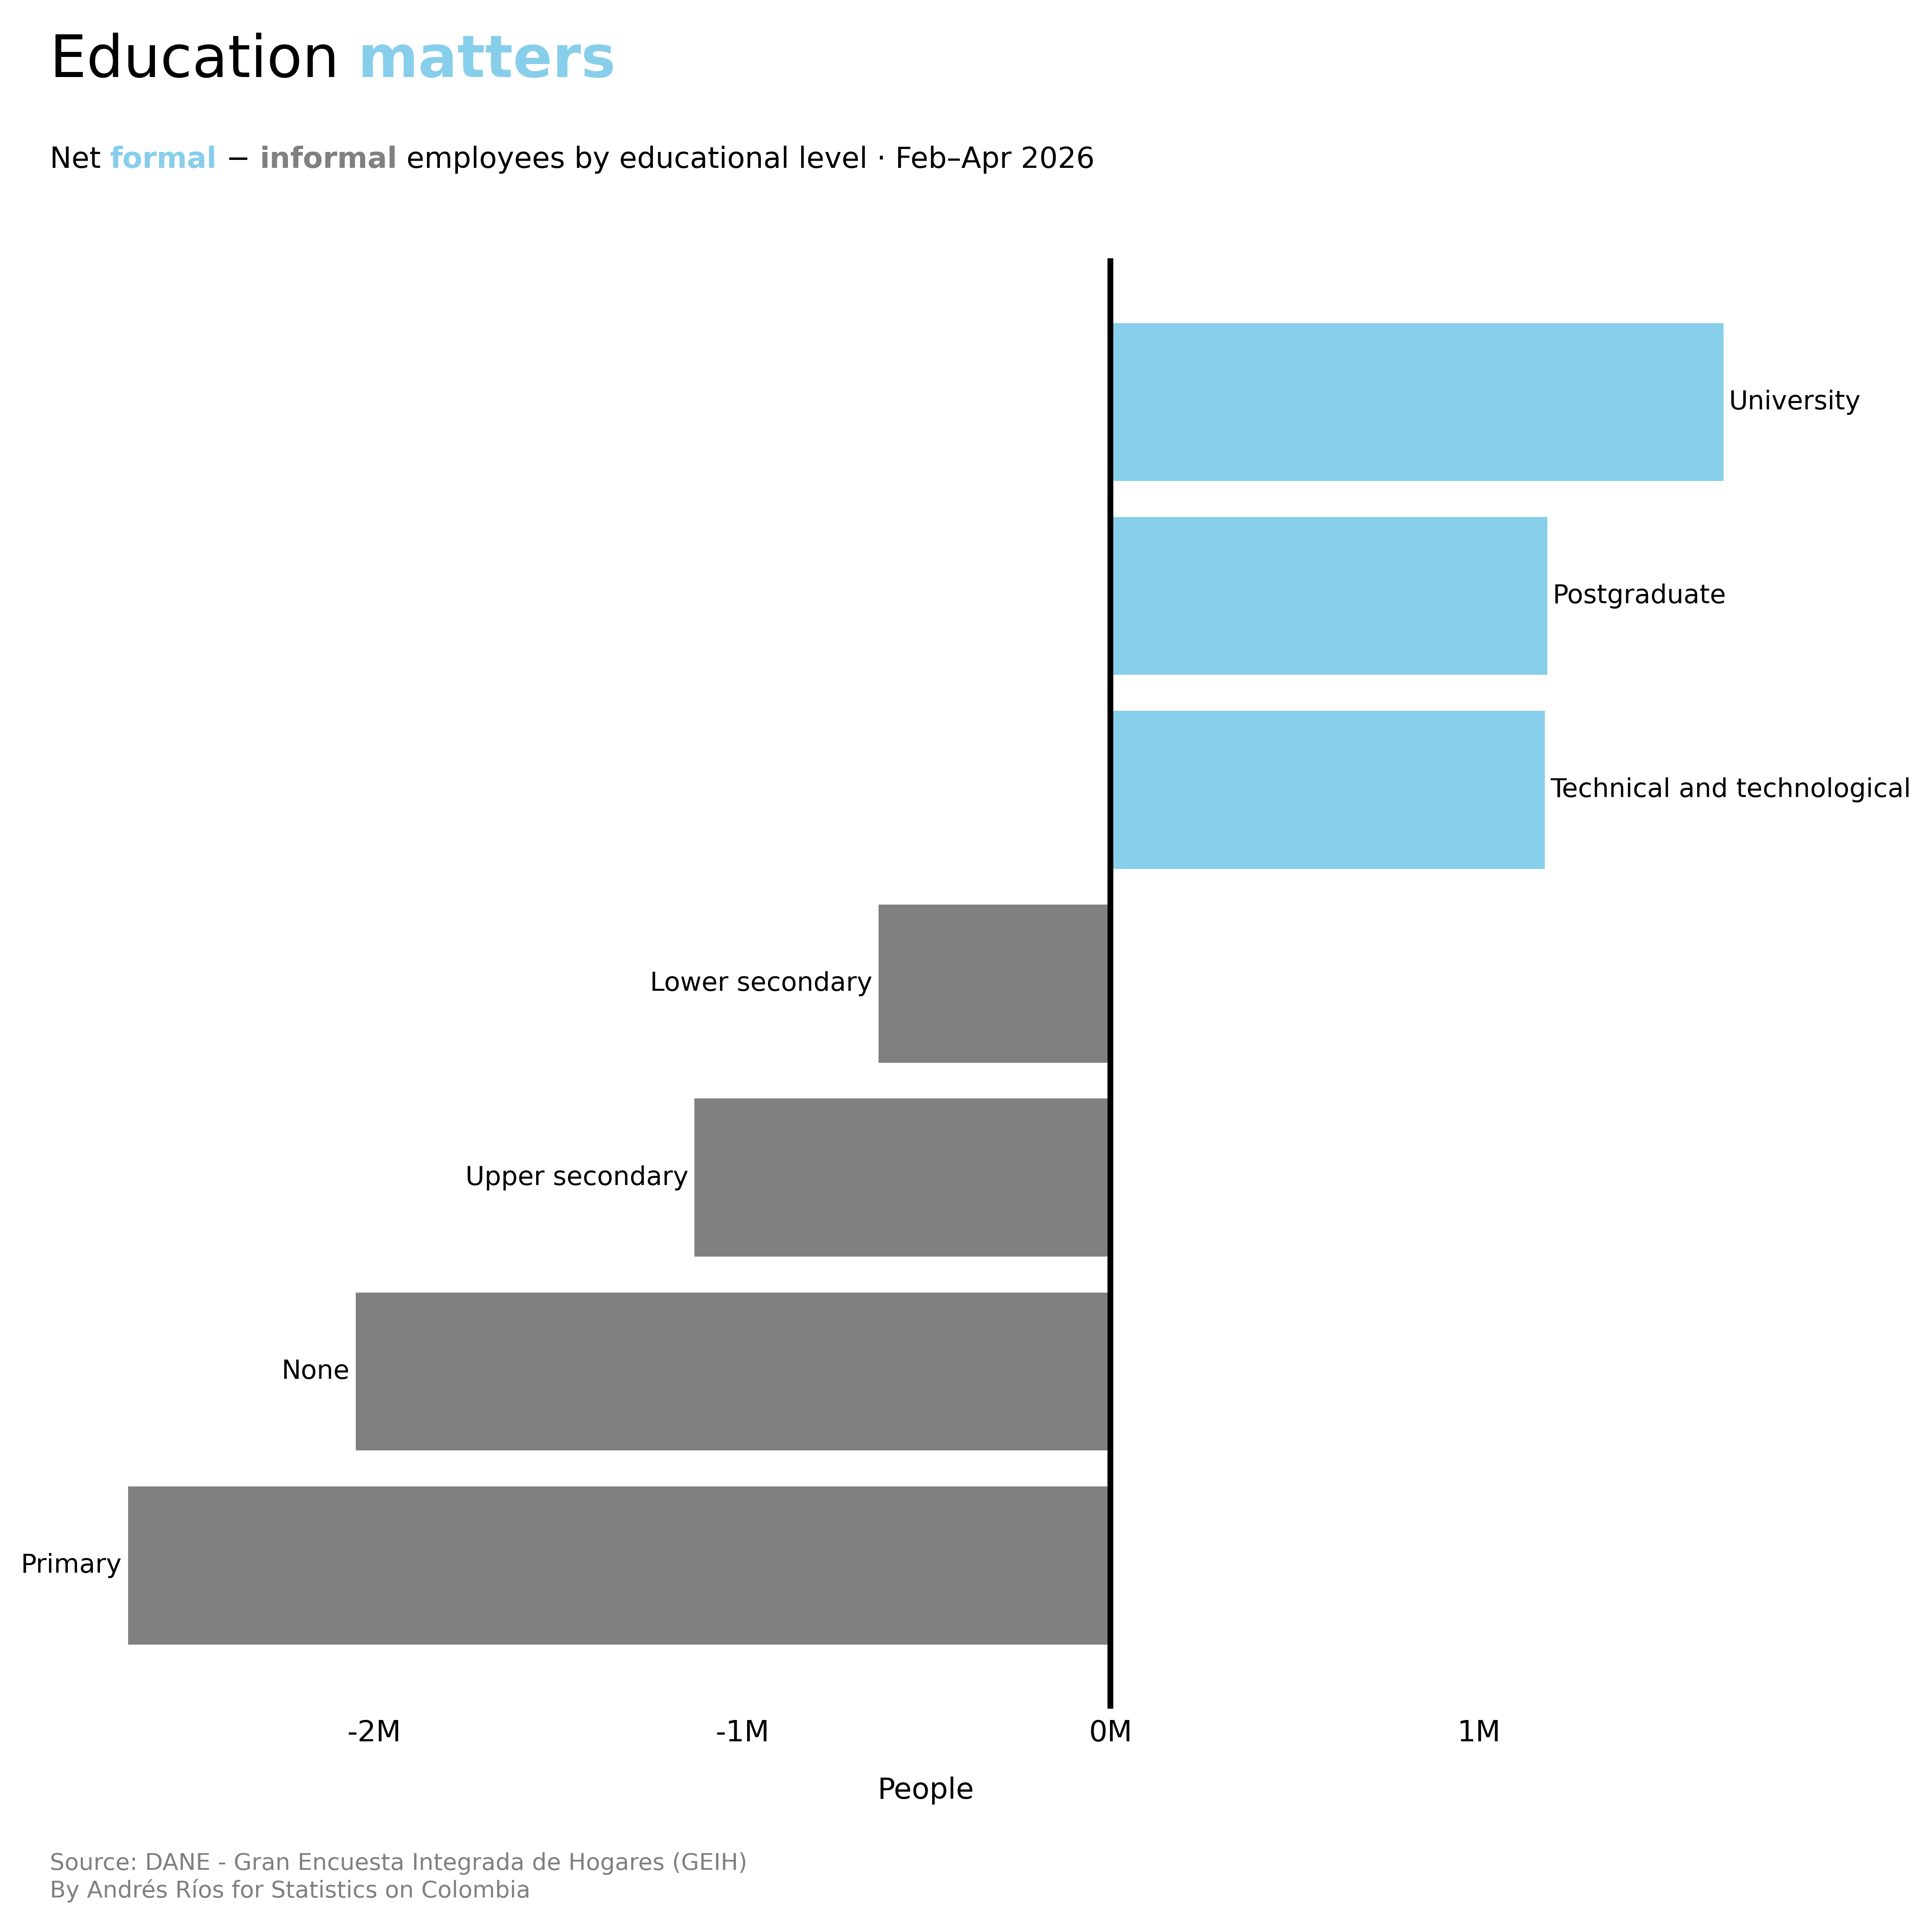

In [178]:
plt.figure(figsize=(10.8, 9), dpi=500)

bars = plt.barh(net_difference.index, net_difference.values)
for bar in bars:
    if bar.get_width() > 0:
        bar.set_color("skyblue")
    else:
        bar.set_color("gray")

plt.gca().set_yticks([])  

for i, (label, value) in enumerate(zip(net_difference.index, net_difference.values)):
    if value > 0:
        plt.text(value + 20000, i, label, ha="left", va="center", fontsize=9)
    else:
        plt.text(value - 20000, i, label, ha="right", va="center", fontsize=9)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000000)}M'))

for side in ["top", "left", "right", "bottom"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.xlabel("People", labelpad=10, fontsize=10)

plt.axvline(0, ymin=0, color="black", linewidth=2)

fig_text(x=0.125, y=1,
         s="Education <matters>",
         highlight_textprops=[{"color": "skyblue", "fontweight": "bold"}],
         fontsize=20)

fig_text(x=0.125, y=0.94,
         s="Net <formal> − <informal> employees by educational level · Feb–Apr 2026",
         highlight_textprops=[{"color": "skyblue", "fontweight": "bold"}, {"color": "gray", "fontweight": "bold"}],
         fontsize=10)

fig = plt.gcf()
fig.text(0.125, 0.01, "Source: DANE - Gran Encuesta Integrada de Hogares (GEIH)\nBy Andrés Ríos "
        "for Statistics on Colombia", 
         fontsize=8, color="gray")

plt.show()